In [32]:
!pip install pandas numpy scikit-learn nltk streamlit matplotlib seaborn wordcloud joblib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

In [ ]:
df = pd.read_csv("../data/cleaned_news.csv")

In [35]:
df.head()

,title,text,subject,date,label,clean_text,text_length
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,21st century wire say ben stein reputable prof...,99
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,washington reuters u president donald trump re...,468
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,reuters puerto rico governor ricardo rossello ...,173
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,monday donald trump embarrassed country accide...,106
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,glasgow scotland reuters u presidential candid...,310


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43822 entries, 0 to 43821
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   title        43822 non-null  str  
 1   text         43822 non-null  str  
 2   subject      43822 non-null  str  
 3   date         43822 non-null  str  
 4   label        43822 non-null  int64
 5   clean_text   43822 non-null  str  
 6   text_length  43822 non-null  int64
dtypes: int64(2), str(5)
memory usage: 185.4 MB


In [37]:
df.shape

(43822, 7)

In [38]:
df["label"].value_counts()

label
0    22612
1    21210
Name: count, dtype: int64

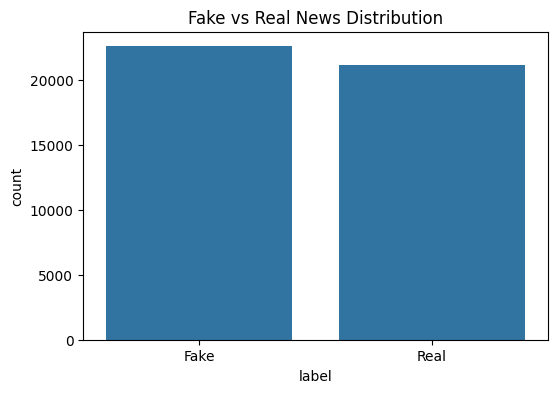

In [39]:

plt.figure(figsize=(6,4))

sns.countplot(
    x=df["label"]
)

plt.xticks(
    [0,1],
    ["Fake", "Real"]
)

plt.title("Fake vs Real News Distribution")

plt.show()

In [40]:
df["char_count"] = df["clean_text"].apply(len)

In [41]:
df["word_count"] = df["clean_text"].apply(
    lambda x: len(str(x).split())
)

In [42]:
df[["char_count", "word_count"]].describe()

,char_count,word_count
count,43822.000000,43822.000000
mean,1750.790128,237.622518
std,1524.632518,202.832233
min,28.000000,6.000000
25%,912.000000,125.000000
50%,1523.000000,208.000000
75%,2170.000000,295.000000
max,38097.000000,4920.000000


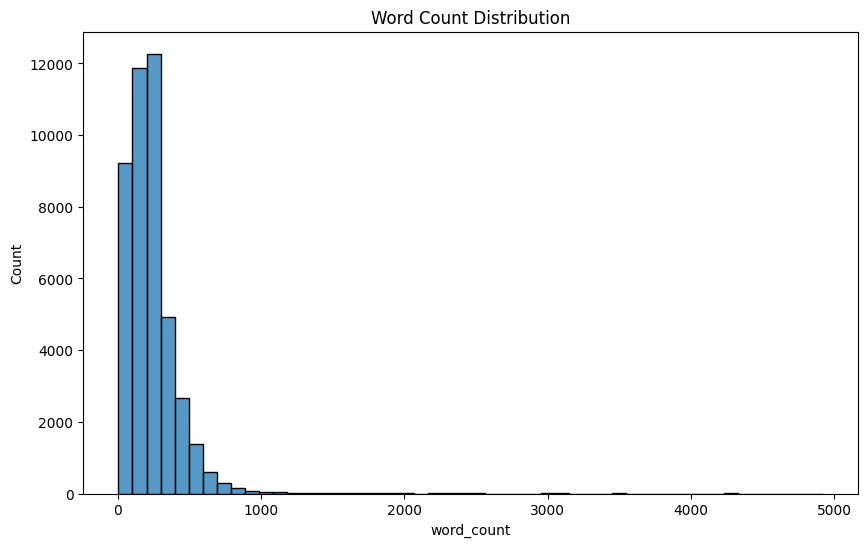

In [43]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["word_count"],
    bins=50
)

plt.title("Word Count Distribution")

plt.show()

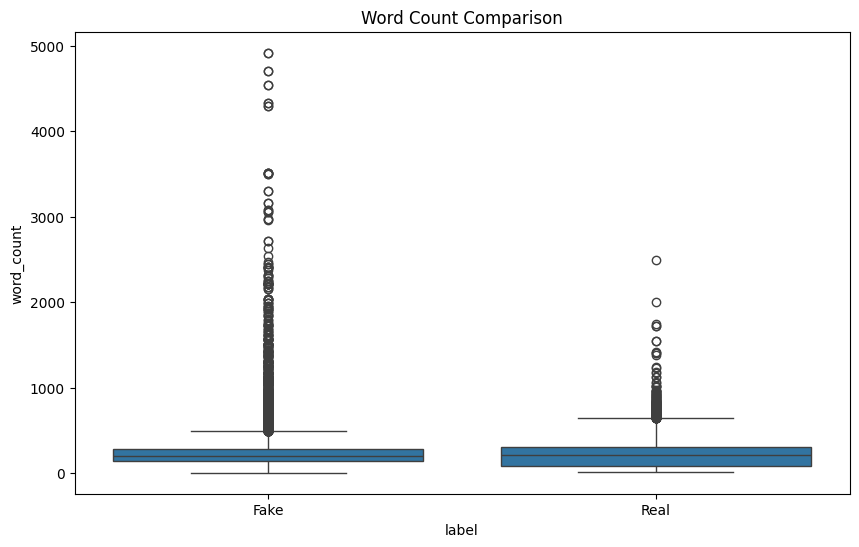

In [44]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="label",
    y="word_count",
    data=df
)

plt.xticks(
    [0,1],
    ["Fake", "Real"]
)

plt.title("Word Count Comparison")

plt.show()

In [45]:
all_words = " ".join(df["clean_text"])

In [46]:
words = all_words.split()

In [47]:
word_freq = Counter(words)

In [48]:
common_words = word_freq.most_common(20)

common_words

[('said', 128852),
 ('trump', 127499),
 ('u', 62966),
 ('state', 57909),
 ('would', 54582),
 ('president', 52783),
 ('people', 41159),
 ('republican', 37979),
 ('one', 36587),
 ('year', 33284),
 ('also', 30972),
 ('new', 30754),
 ('reuters', 28472),
 ('government', 28223),
 ('clinton', 28050),
 ('house', 27499),
 ('donald', 27471),
 ('time', 26735),
 ('say', 25185),
 ('obama', 24762)]

In [49]:
common_df = pd.DataFrame(
    common_words,
    columns=["Word", "Frequency"]
)

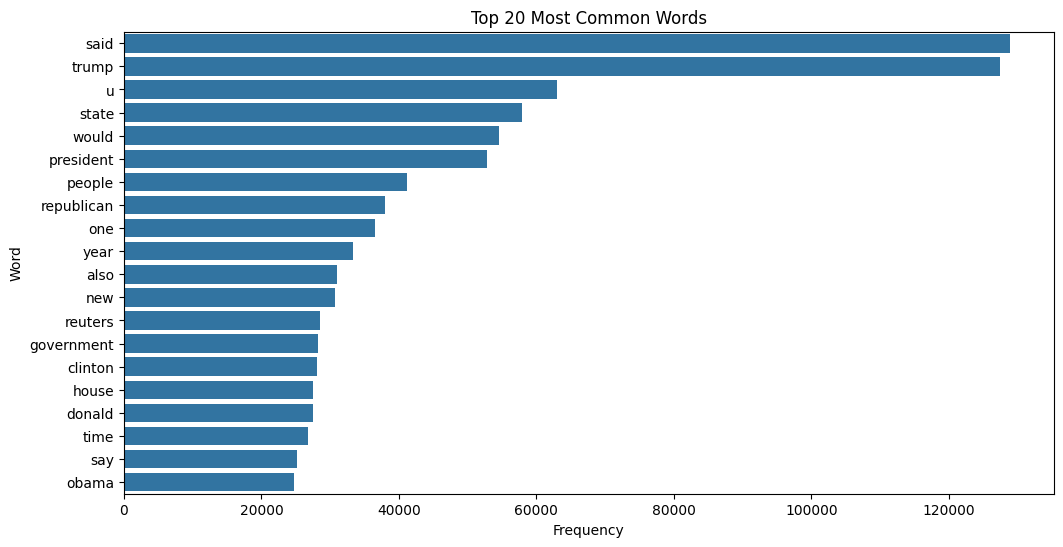

In [50]:
plt.figure(figsize=(12,6))

sns.barplot(
    x="Frequency",
    y="Word",
    data=common_df
)

plt.title("Top 20 Most Common Words")

plt.show()

In [51]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(all_words)

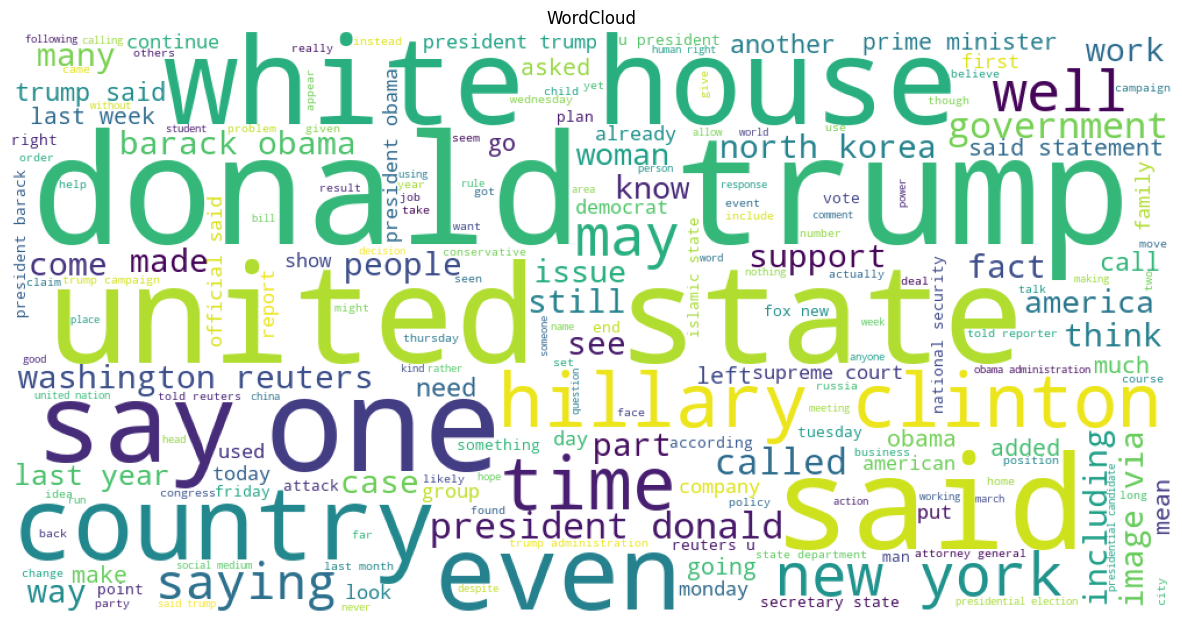

In [52]:
plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("WordCloud")

plt.show()

In [53]:
fake_words = " ".join(
    df[df["label"] == 0]["clean_text"]
)

In [54]:
fake_cloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(fake_words)

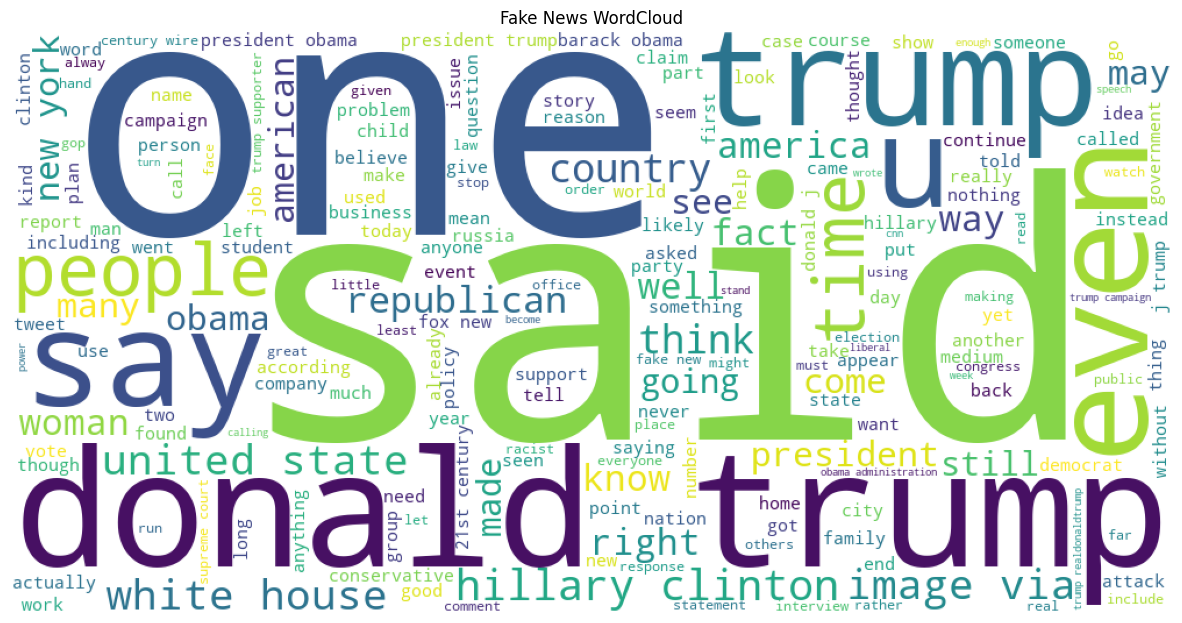

In [55]:
plt.figure(figsize=(15,8))

plt.imshow(fake_cloud)

plt.axis("off")

plt.title("Fake News WordCloud")

plt.show()

In [56]:
real_words = " ".join(
    df[df["label"] == 1]["clean_text"]
)

In [57]:
real_cloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(real_words)

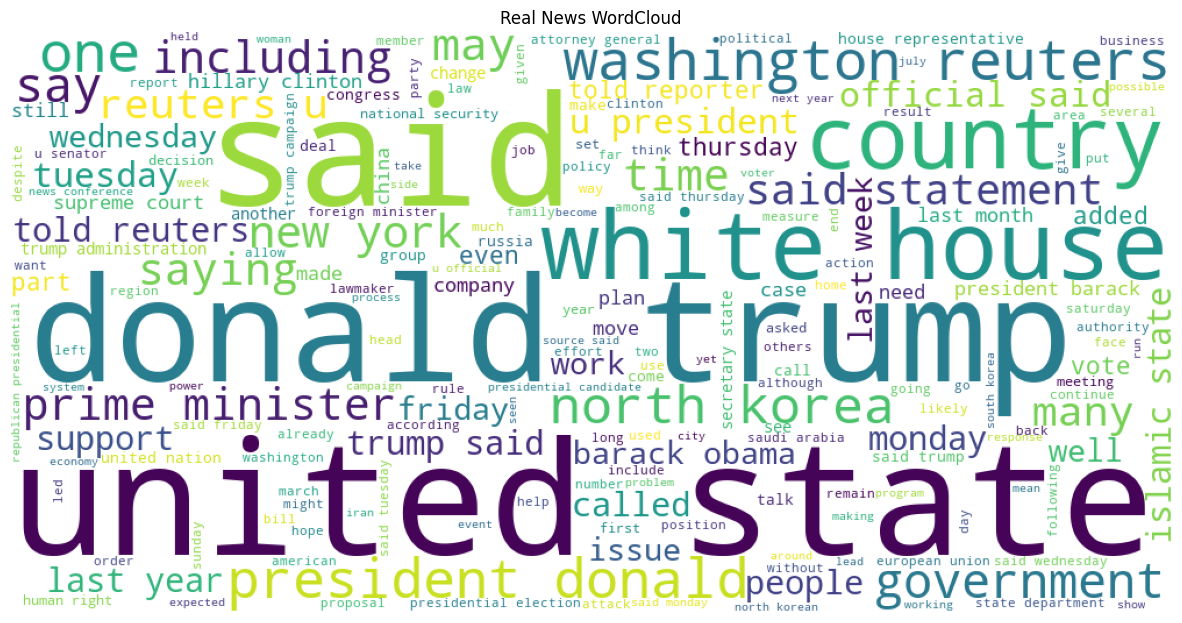

In [58]:
plt.figure(figsize=(15,8))

plt.imshow(real_cloud)

plt.axis("off")

plt.title("Real News WordCloud")

plt.show()

In [59]:
Q1 = df["word_count"].quantile(0.25)
Q3 = df["word_count"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df["word_count"] >= lower) &
    (df["word_count"] <= upper)
]

In [63]:
import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [64]:
custom_stopwords = [
    "said",
    "reuters",
    "trump",
    "donald",
    "president",
    "u",
    "us"
]

In [65]:
stop_words.update(custom_stopwords)

In [67]:
def remove_stopwords(text):

    words = text.split()

    filtered_words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(filtered_words)

In [69]:
import re

def clean_text(text):

    text = str(text).lower()

    # URL kaldır
    text = re.sub(r"http\S+", "", text)

    # www kaldır
    text = re.sub(r"www\S+", "", text)

    # html tag kaldır
    text = re.sub(r"<.*?>", "", text)

    # noktalama kaldır
    text = re.sub(r"[^\w\s]", "", text)

    # fazla boşluk kaldır
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [71]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):

    words = text.split()

    lemmatized_words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(lemmatized_words)

In [72]:
df["clean_text"] = df["text"].apply(clean_text)

df["clean_text"] = df["clean_text"].apply(remove_stopwords)

df["clean_text"] = df["clean_text"].apply(lemmatize_text)

In [73]:
all_words = " ".join(df["clean_text"])

words = all_words.split()

word_freq = Counter(words)

common_words = word_freq.most_common(20)

In [74]:
common_df = pd.DataFrame(
    common_words,
    columns=["Word", "Frequency"]
)

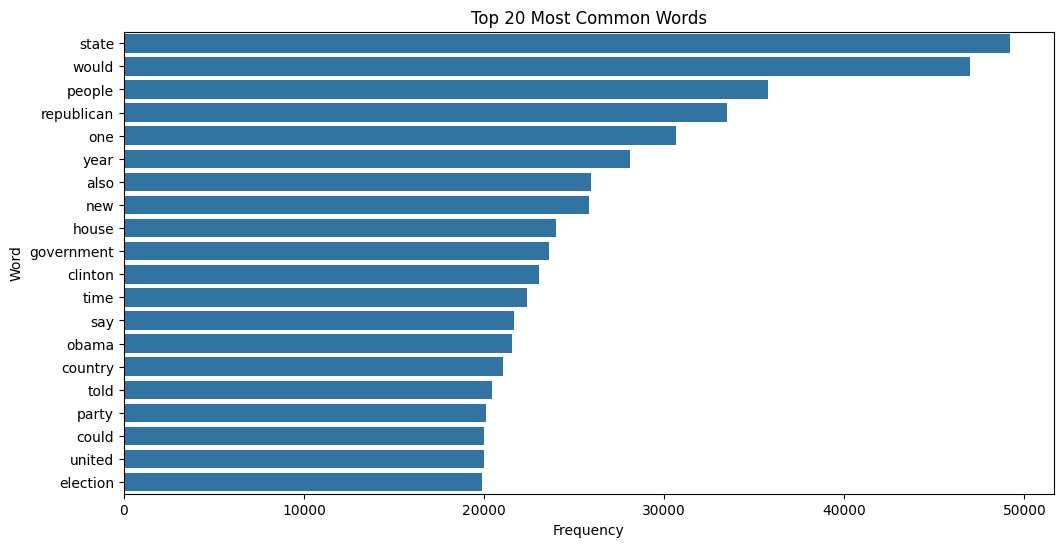

In [75]:
plt.figure(figsize=(12,6))

sns.barplot(
    x="Frequency",
    y="Word",
    data=common_df
)

plt.title("Top 20 Most Common Words")

plt.show()

In [76]:
all_words = " ".join(df["clean_text"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(all_words)

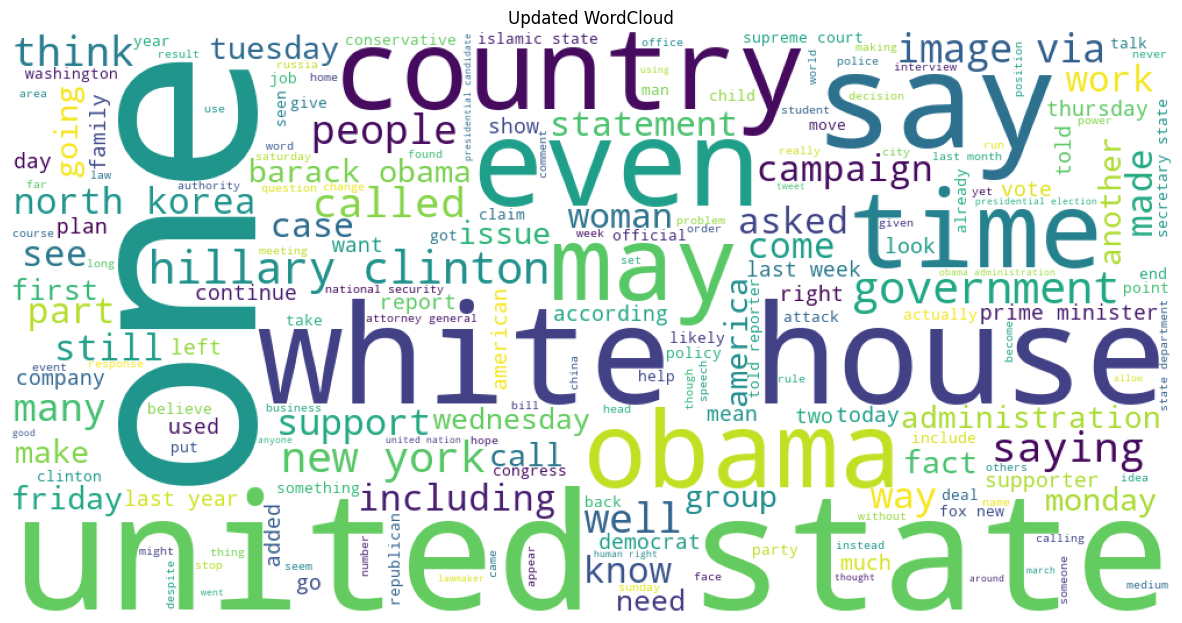

In [77]:
plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Updated WordCloud")

plt.show()

In [78]:
fake_words = " ".join(
    df[df["label"] == 0]["clean_text"]
)

fake_cloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(fake_words)

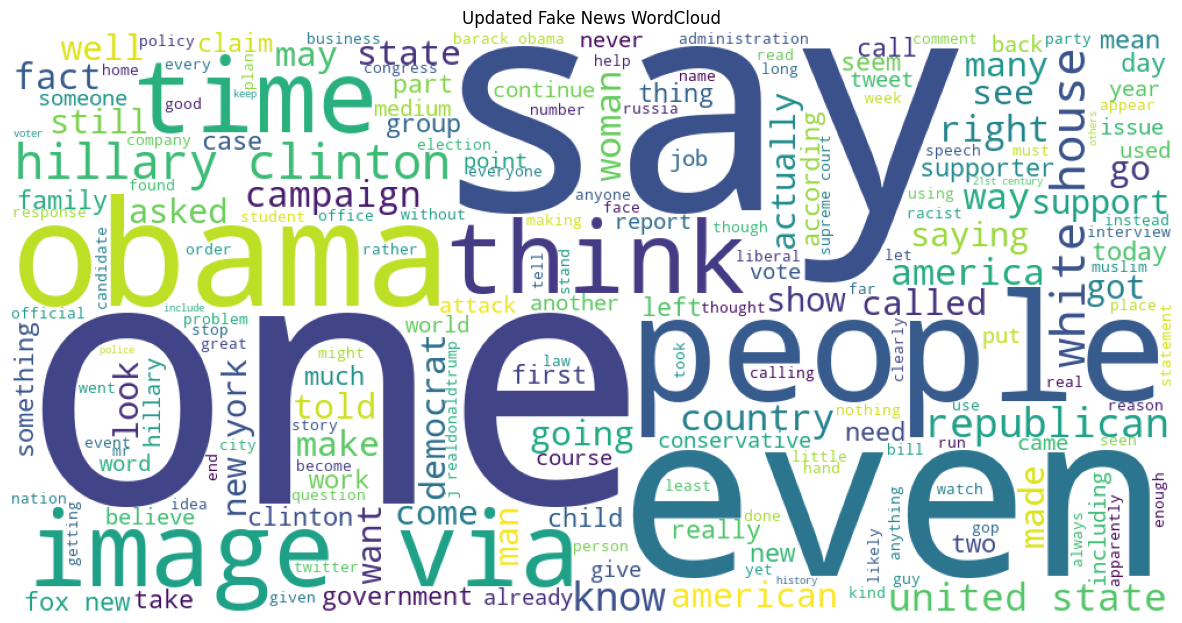

In [80]:
plt.figure(figsize=(15,8))

plt.imshow(fake_cloud)

plt.axis("off")

plt.title("Updated Fake News WordCloud")

plt.show()

In [81]:
real_words = " ".join(
    df[df["label"] == 1]["clean_text"]
)

real_cloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(real_words)

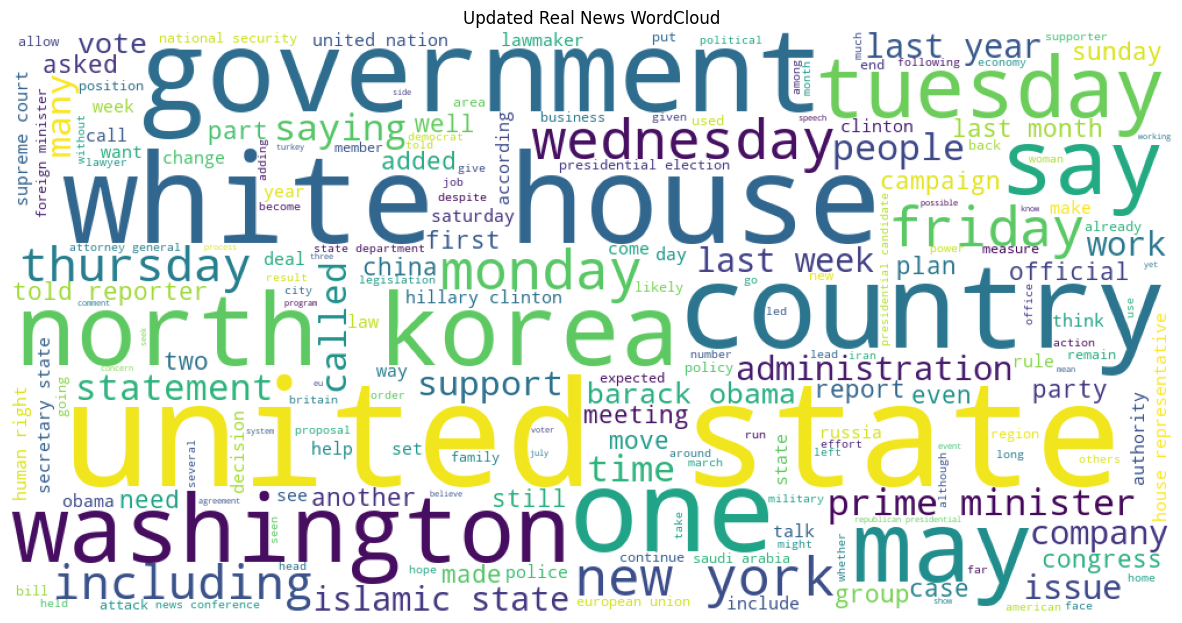

In [82]:
plt.figure(figsize=(15,8))

plt.imshow(real_cloud)

plt.axis("off")

plt.title("Updated Real News WordCloud")

plt.show()

In [83]:
extra_stopwords = {
    "say",
    "would",
    "could",
    "also",
    "one",
    "may",
    "even",
    "people",
    "told",
    "new",
    "time"
}

In [84]:
stop_words.update(extra_stopwords)

In [85]:
df["clean_text"] = df["text"].apply(clean_text)

df["clean_text"] = df["clean_text"].apply(remove_stopwords)

df["clean_text"] = df["clean_text"].apply(lemmatize_text)

In [86]:
df.to_csv(
    "../data/final_cleaned_news.csv",
    index=False
)